In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import lightgbm as lgb
import warnings

warnings.filterwarnings('ignore')
plt.rcParams['font.sans-serif'] = ['SimHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

print("✓ All libraries imported successfully")
print(f"  • LightGBM version: {lgb.__version__}")

✓ All libraries imported successfully
  • LightGBM version: 4.6.0


## Step 1: Data Loading and Timestamp Parsing

In [2]:
# Load data
try:
    df = pd.read_excel('CO2_capacity.xlsx', engine='openpyxl')
    print(f"✓ Data loaded successfully, shape: {df.shape}")
except Exception as e:
    raise RuntimeError(f"Read failed: {e}")

# Display first few rows
print(f"\nFirst 5 rows of the dataset:")
print(df.head())

# Define key columns
time_col = df.columns[0]  # The first column is timestamp
target_col = df.columns[-1]  # The last column is the target (CO2 capacity)

print(f"\nColumn roles:")
print(f"  • Time column: {time_col}")
print(f"  • Target column: {target_col}")
print(f"  • Sampling frequency: 1 minute")
print(f"  • Total records: {len(df)}")

✓ Data loaded successfully, shape: (7200, 59)

First 5 rows of the dataset:
                 Date      PI-2       TI-2         FI-2      PI-3       TI-3  \
0 2020-01-20 00:00:00 -0.053126  34.736652  1543.938721  0.052434  45.023132   
1 2020-01-20 00:01:00 -0.053289  34.732132  1541.767578  0.052564  45.045799   
2 2020-01-20 00:02:00 -0.053386  34.761639  1545.614746  0.052390  45.088932   
3 2020-01-20 00:03:00 -0.053370  34.731682  1544.225952  0.052236  45.071358   
4 2020-01-20 00:04:00 -0.053144  34.718353  1540.848267  0.052370  45.036755   

       O2-3      TI-32      TI-33      TI-34  ...        FI-16      TI-16  \
0  5.170577  37.777477  50.215652  61.217957  ...  9634.049805  34.619560   
1  5.139907  37.836792  50.203251  61.241829  ...  9661.376953  34.598999   
2  5.078373  37.840168  50.180534  61.217957  ...  9662.280273  34.551292   
3  4.915955  37.849812  50.215652  61.322845  ...  9656.855469  34.583843   
4  5.042109  37.914433  50.229359  61.233147  ...  9641.30

## Step 2: Feature Selection and Chronological Split

In [3]:
# Selected 11 features (from correlation analysis)
selected_features = ['TI-34', 'TI-33',  'FI-30', 'FI-38', 'TI-4', 'TI-19', 'TI-12', 'TI-22', 'TI-24','TI-28', 'Level Reboiler']

# Check whether all selected features exist
missing_features = [f for f in selected_features if f not in df.columns]
if missing_features:
    print(f"⚠ Warning: The following features are missing: {missing_features}")
    print(f"Actual columns: {list(df.columns)}")
    selected_features = [f for f in selected_features if f in df.columns]
    print(f"Using available features only: {selected_features}")

print(f"\nFeatures in use (total {len(selected_features)}):")
for i, feat in enumerate(selected_features, 1):
    print(f"  {i}. {feat}")

# Extract features and target
X = df[selected_features].copy()
y = df[target_col].copy()

# Handle missing values (fill with median)
X.fillna(X.median(), inplace=True)
y.fillna(y.median(), inplace=True)

print(f"\nTarget variable statistics:")
print(f"  • Min: {y.min():.6f}")
print(f"  • Max: {y.max():.6f}")
print(f"  • Mean: {y.mean():.6f}")
print(f"  • Std: {y.std():.6f}")

# Chronological split: first 80% for training, last 20% for testing
split_idx = int(len(df) * 0.8)

X_train_raw = X.iloc[:split_idx].reset_index(drop=True)
X_test_raw = X.iloc[split_idx:].reset_index(drop=True)
y_train_raw = y.iloc[:split_idx].reset_index(drop=True)
y_test_raw = y.iloc[split_idx:].reset_index(drop=True)

# Save timeline information for visualization
time_series = pd.to_datetime(df[time_col])
time_train = time_series.iloc[:split_idx].reset_index(drop=True)
time_test = time_series.iloc[split_idx:].reset_index(drop=True)

print(f"\nChronological split results:")
print(f"  • Training data: {len(X_train_raw)} rows (first 80%)")
print(f"  • Test data: {len(X_test_raw)} rows (last 20%)")


Features in use (total 11):
  1. TI-34
  2. TI-33
  3. FI-30
  4. FI-38
  5. TI-4
  6. TI-19
  7. TI-12
  8. TI-22
  9. TI-24
  10. TI-28
  11. Level Reboiler

Target variable statistics:
  • Min: 0.582062
  • Max: 0.948009
  • Mean: 0.864631
  • Std: 0.045872

Chronological split results:
  • Training data: 5760 rows (first 80%)
  • Test data: 1440 rows (last 20%)


## Step 3: Use Raw Features Directly (LightGBM Is Not Sensitive to Feature Scaling)

In [4]:
# LightGBM is tree-based and not sensitive to feature scaling, so raw data is used directly
print("✓ Using raw features (no standardization)")
print(f"\nTraining feature statistics (raw values):")
print(f"  • Mean: {X_train_raw.mean().values}")
print(f"  • Variance: {X_train_raw.var().values}")
print(f"  • Min: {X_train_raw.min().values}")
print(f"  • Max: {X_train_raw.max().values}")

✓ Using raw features (no standardization)

Training feature statistics (raw values):
  • Mean: [ 63.01994574  51.6572464  281.50556714 373.27202882  46.57372443
  47.50509909  43.18887455  63.33777058  41.68796348  90.03880434
  70.2182511 ]
  • Variance: [5.58310455e+00 3.45825570e+00 4.30075976e+02 1.28032381e+03
 5.54920509e+00 4.53039475e+00 1.14720665e+01 7.99550261e+00
 2.43238441e+00 2.96248279e+00 7.93687253e-01]
  • Min: [5.17452812e+01 4.53763733e+01 9.26589279e+01 6.99569806e-02
 3.56008873e+01 3.52613869e+01 3.90961189e+01 4.29024811e+01
 3.76834412e+01 7.49711609e+01 6.86522903e+01]
  • Max: [ 68.80599976  55.41588593 437.49478149 473.13320923  55.4248085
  62.66413498  55.8631897   70.11131287  47.23034668  96.08318329
  74.99525452]


## Step 4: Sliding Window Construction

**Rule:** Use feature values from the previous 10 time steps (10 minutes) as input to predict the target at the next time step (the 11th minute).

In [5]:
def create_sliding_windows(X, y, window_size=10):
    """
    Build sliding-window samples.
    
    Parameters:
      X: Feature data (n_samples, n_features)
      y: Target data (n_samples,)
      window_size: Window length (default: 10)
    
    Returns:
      X_windows: Windowed features (n_windows, window_size * n_features)
      y_windows: Windowed targets (n_windows,)
    """
    X_windows = []
    y_windows = []
    
    for i in range(len(X) - window_size):
        # Take features from i to i+window_size-1 and flatten into one row
        window = X.iloc[i:i+window_size].values.flatten()
        X_windows.append(window)
        
        # Target is the value at time step i+window_size
        y_windows.append(y.iloc[i+window_size])
    
    return np.array(X_windows), np.array(y_windows)

# Build training windows
X_train_windows, y_train_windows = create_sliding_windows(X_train_raw, y_train_raw, window_size=10)

# Build test windows
X_test_windows, y_test_windows = create_sliding_windows(X_test_raw, y_test_raw, window_size=10)

print(f"✓ Sliding-window construction completed")
print(f"\nTraining data:")
print(f"  • Number of samples: {X_train_windows.shape[0]}")
print(f"  • Feature dimension: {X_train_windows.shape[1]} (10 minutes × {len(selected_features)} features)")
print(f"\nTest data:")
print(f"  • Number of samples: {X_test_windows.shape[0]}")
print(f"  • Feature dimension: {X_test_windows.shape[1]}")

print(f"\nSample example (first sample in training set):")
print(f"  Input shape: {X_train_windows[0].shape}")
print(f"  Input (first 20 values): {X_train_windows[0][:20]}")
print(f"  Target value: {y_train_windows[0]}")

✓ Sliding-window construction completed

Training data:
  • Number of samples: 5750
  • Feature dimension: 110 (10 minutes × 11 features)

Test data:
  • Number of samples: 1430
  • Feature dimension: 110

Sample example (first sample in training set):
  Input shape: (110,)
  Input (first 20 values): [ 61.21795654  50.21565247 281.14794922 366.61743164  45.44509125
  46.43609619  41.40271378  61.92232895  40.36348724  89.95625305
  70.96716309  61.24182892  50.20325089 277.5836792  368.57546997
  45.44147491  46.3895607   41.40874481  61.90945435  40.37795639]
  Target value: 0.846168723536747


## Step 4-B: Dataset Summary

Use 80% of the original data for training and 20% for testing.

In [6]:
print(f"✓ Dataset split completed")
print(f"\nDataset summary:")
print(f"  • Training set: {X_train_windows.shape[0]} samples")
print(f"  • Test set: {X_test_windows.shape[0]} samples")
print(f"  • Feature dimension: {X_train_windows.shape[1]}")
print(f"\nSplit ratio:")
print(f"  • Training set: 80%")
print(f"  • Test set: 20%")

✓ Dataset split completed

Dataset summary:
  • Training set: 5750 samples
  • Test set: 1430 samples
  • Feature dimension: 110

Split ratio:
  • Training set: 80%
  • Test set: 20%


## Step 5: LightGBM Model Training (with RandomizedSearchCV)

In [7]:
import numpy as np
import lightgbm as lgb

from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import (
    r2_score,
    mean_squared_error,
    mean_absolute_error
)

from scipy.stats import randint, uniform

# =============================================================================
print("=" * 80)
print("LightGBM Model Training (RandomizedSearchCV)")
print("=" * 80)

# =============================================================================
# Step 1: Define the base LightGBM model
# =============================================================================
lgb_model = lgb.LGBMRegressor(
    random_state=42,
    n_jobs=-1,
    verbose=-1,
    metric='rmse'
)

# =============================================================================
# Step 2: Define parameter distributions for RandomizedSearch (anti-overfitting)
# =============================================================================
param_distributions = {
    'n_estimators': randint(80, 150),           # Fewer trees (was 150-260)
    'max_depth': randint(3, 6),                 # Shallower trees (was 4-9)
    'num_leaves': randint(15, 40),              # Fewer leaves (was 20-80)
    'learning_rate': uniform(0.01, 0.03),       # Lower learning rate (was 0.02-0.05)
    'min_child_samples': randint(20, 50),       # Larger min samples per leaf (was 10-30)
    'subsample': uniform(0.6, 0.25),            # Lower row sampling ratio (was 0.75-0.95)
    'colsample_bytree': uniform(0.6, 0.25),     # Lower column sampling ratio (was 0.75-0.95)
    'min_child_weight': uniform(0.001, 0.01)    # Added: minimum child weight
}

print("\n[RandomizedSearch Parameter Space (anti-overfitting)]")
for k in param_distributions:
    print(f"  • {k}")

# =============================================================================
# Step 3: Initialize RandomizedSearchCV
# =============================================================================
random_search = RandomizedSearchCV(
    estimator=lgb_model,
    param_distributions=param_distributions,
    n_iter=30,                # Number of random trials
    cv=3,
    scoring='r2',
    n_jobs=-1,
    verbose=1,
    random_state=42
)

print("\n[RandomizedSearchCV Configuration]")
print("  • Search iterations: 30")
print("  • Cross-validation: 3-fold")
print("  • Optimization target: R²")
print("  • Parallelism: all CPU cores")

# =============================================================================
# Step 4: Run RandomizedSearch
# =============================================================================
print("\nRunning RandomizedSearchCV ...")
random_search.fit(X_train_windows, y_train_windows)

best_params = random_search.best_params_

print("\n✓ Search completed")
print("\n[Best Hyperparameters]")
for k, v in best_params.items():
    print(f"  • {k}: {v}")

print(f"\n[Best CV R²]: {random_search.best_score_:.4f}")

# =============================================================================
# Step 5: Train final model using best hyperparameters
# =============================================================================
print("\n" + "=" * 80)
print("Training final model with best hyperparameters")
print("=" * 80)

final_model = lgb.LGBMRegressor(
    **best_params,
    reg_lambda=2.0,          # Stronger L2 regularization (was 0.8)
    reg_alpha=0.5,           # Added L1 regularization (was 0.0)
    min_split_gain=0.01,     # Added: minimum split gain
    random_state=42,
    n_jobs=-1,
    verbose=-1,
    metric='rmse'
)

final_model.fit(X_train_windows, y_train_windows)

print("✓ Final model training completed")
print(f"  • Number of training samples: {X_train_windows.shape[0]}")
print(f"  • Feature dimension: {X_train_windows.shape[1]}")

# =============================================================================
# Step 6: Performance evaluation
# =============================================================================
print("\n" + "=" * 80)
print("Performance Evaluation")
print("=" * 80)

# Prediction
y_train_pred = final_model.predict(X_train_windows)

# Training metrics
train_r2 = r2_score(y_train_windows, y_train_pred)
train_rmse = np.sqrt(mean_squared_error(y_train_windows, y_train_pred))
train_mae = mean_absolute_error(y_train_windows, y_train_pred)

# =============================================================================
# WQL metric
# =============================================================================
def calculate_wql(y_true, y_pred, alpha=0.5):
    errors = y_true - y_pred
    return np.mean(np.where(errors > 0, alpha * errors, (alpha - 1) * errors))

train_wql = calculate_wql(y_train_windows, y_train_pred)

# =============================================================================
# Output
# =============================================================================
print("\n[Training Set Performance]")
print(f"  • R²   : {train_r2:.4f}")
print(f"  • RMSE : {train_rmse:.6f}")
print(f"  • MAE  : {train_mae:.6f}")
print(f"  • WQL  : {train_wql:.6f}")


LightGBM Model Training (RandomizedSearchCV)

[RandomizedSearch Parameter Space (anti-overfitting)]
  • n_estimators
  • max_depth
  • num_leaves
  • learning_rate
  • min_child_samples
  • subsample
  • colsample_bytree
  • min_child_weight

[RandomizedSearchCV Configuration]
  • Search iterations: 30
  • Cross-validation: 3-fold
  • Optimization target: R²
  • Parallelism: all CPU cores

Running RandomizedSearchCV ...
Fitting 3 folds for each of 30 candidates, totalling 90 fits

✓ Search completed

[Best Hyperparameters]
  • colsample_bytree: 0.7619225301353405
  • learning_rate: 0.010015611309859476
  • max_depth: 3
  • min_child_samples: 28
  • min_child_weight: 0.0040478125815802905
  • n_estimators: 149
  • num_leaves: 22
  • subsample: 0.7335223548438605

[Best CV R²]: 0.2024

Training final model with best hyperparameters
✓ Final model training completed
  • Number of training samples: 5750
  • Feature dimension: 110

Performance Evaluation

[Training Set Performance]
  • R²   

## Step 6: Test Set Performance Evaluation

In [8]:
# Predict on the test set
y_test_pred = final_model.predict(X_test_windows)

# Compute evaluation metrics
test_r2 = r2_score(y_test_windows, y_test_pred)
test_rmse = np.sqrt(mean_squared_error(y_test_windows, y_test_pred))
test_mae = mean_absolute_error(y_test_windows, y_test_pred)

# Compute WQL (Weighted Quantile Loss)
def calculate_wql(y_true, y_pred, alpha=0.5):
    """
    Compute Weighted Quantile Loss (WQL).
    
    Parameters:
      y_true: Ground truth
      y_pred: Prediction
      alpha: Quantile level (0-1), where 0.5 denotes median
    
    Returns:
      WQL value; lower is better
    
    Interpretation:
      - When y_pred < y_true (underestimation), loss is alpha * |error|
      - When y_pred > y_true (overestimation), loss is (1-alpha) * |error|
      - At alpha=0.5, under/over estimations are penalized equally
      - Useful for evaluating prediction balance and systematic bias
    """
    errors = y_true - y_pred
    return np.mean(np.where(errors > 0, alpha * errors, (alpha - 1) * errors))

test_wql = calculate_wql(y_test_windows, y_test_pred, alpha=0.5)

# Compute residuals
residuals = y_test_windows - y_test_pred
residuals_std = np.std(residuals)
residuals_mean = np.mean(residuals)

print("="*80)
print("Test Set Performance Evaluation")
print("="*80)

print(f"\n[Prediction Accuracy Metrics]")
print(f"  • R² score: {test_r2:.4f}")
print(f"    └─ Interpretation: the model explains {test_r2*100:.2f}% of target variance")
print(f"  • RMSE (Root Mean Squared Error): {test_rmse:.6f}")
print(f"    └─ Interpretation: average prediction deviation")
print(f"  • MAE (Mean Absolute Error): {test_mae:.6f}")
print(f"    └─ Interpretation: average absolute deviation")
print(f"  • WQL (Weighted Quantile Loss): {test_wql:.6f}")
print(f"    └─ Interpretation: evaluates prediction symmetry and balance across under/over estimates")

print(f"\n[Actual vs Predicted Statistics]")
print(f"  Actual values:")
print(f"    • Min: {y_test_windows.min():.6f}, Max: {y_test_windows.max():.6f}")
print(f"    • Mean: {y_test_windows.mean():.6f}, Std: {y_test_windows.std():.6f}")
print(f"  Predicted values:")
print(f"    • Min: {y_test_pred.min():.6f}, Max: {y_test_pred.max():.6f}")
print(f"    • Mean: {y_test_pred.mean():.6f}, Std: {y_test_pred.std():.6f}")

print(f"\n[Residual Analysis]")
print(f"  • Residual mean: {residuals_mean:.6f} (closer to 0 is better)")
print(f"  • Residual std: {residuals_std:.6f}")
print(f"  • Residual min: {residuals.min():.6f}")
print(f"  • Residual max: {residuals.max():.6f}")

# Performance comparison summary
print(f"\n[Full-Dataset Performance Comparison]")
print(f"  {'Dataset':<12} {'R²':<10} {'RMSE':<12} {'MAE':<12} {'WQL':<10}")
print(f"  {'-'*56}")
print(f"  {'Train':<12} {train_r2:<10.4f} {train_rmse:<12.6f} {train_mae:<12.6f} {train_wql:<10.6f}")
print(f"  {'Test':<12} {test_r2:<10.4f} {test_rmse:<12.6f} {test_mae:<12.6f} {test_wql:<10.6f}")

Test Set Performance Evaluation

[Prediction Accuracy Metrics]
  • R² score: 0.8502
    └─ Interpretation: the model explains 85.02% of target variance
  • RMSE (Root Mean Squared Error): 0.016096
    └─ Interpretation: average prediction deviation
  • MAE (Mean Absolute Error): 0.013052
    └─ Interpretation: average absolute deviation
  • WQL (Weighted Quantile Loss): 0.006526
    └─ Interpretation: evaluates prediction symmetry and balance across under/over estimates

[Actual vs Predicted Statistics]
  Actual values:
    • Min: 0.735384, Max: 0.914714
    • Mean: 0.852431, Std: 0.041595
  Predicted values:
    • Min: 0.707181, Max: 0.885160
    • Mean: 0.861328, Std: 0.038248

[Residual Analysis]
  • Residual mean: -0.008898 (closer to 0 is better)
  • Residual std: 0.013413
  • Residual min: -0.086783
  • Residual max: 0.047698

[Full-Dataset Performance Comparison]
  Dataset      R²         RMSE         MAE          WQL       
  ----------------------------------------------------

## Step 7: Result Visualization

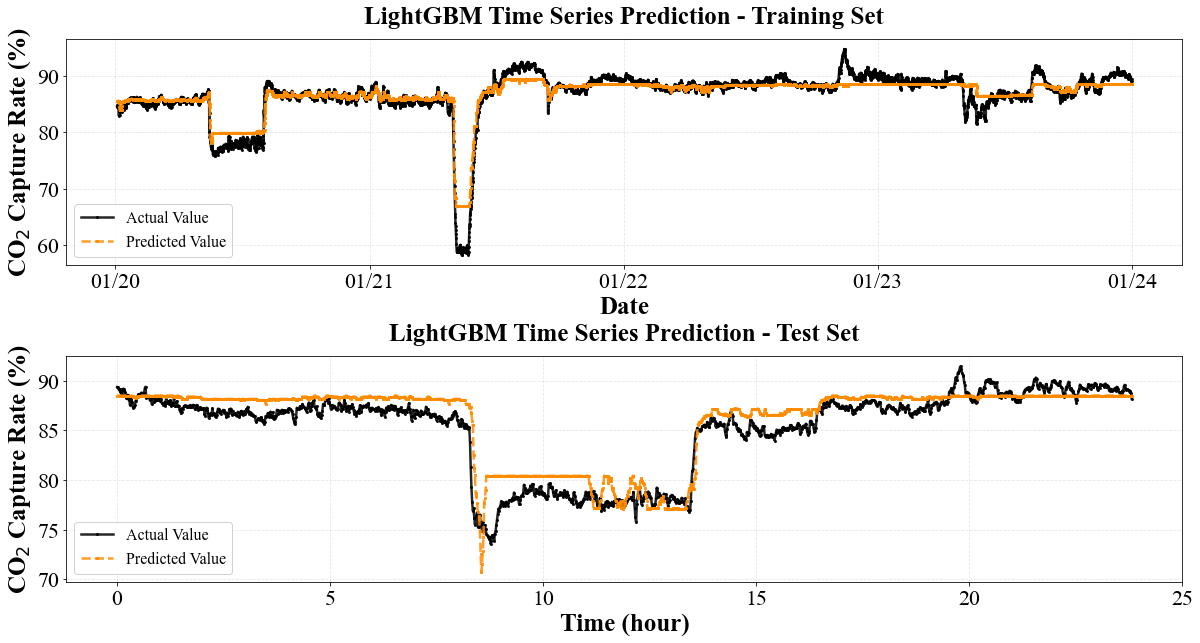

✓ Visualization completed and saved as 'time_series_prediction_results.png'


In [9]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np

# ============================================================================
# Prepare data: handle sliding-window offset and align timelines
# ============================================================================
window_size = 10

# Training set: aligned with y_train_windows (starting from the window_size-th sample)
train_actual_windows = y_train_windows
train_pred_windows = final_model.predict(X_train_windows)
train_time_aligned = time_train.iloc[window_size:window_size + len(train_actual_windows)].reset_index(drop=True)

# Test set: aligned with y_test_windows (starting from the window_size-th sample)
test_actual_windows = y_test_windows
test_pred_windows = y_test_pred
test_time_aligned = time_test.iloc[window_size:window_size + len(test_actual_windows)].reset_index(drop=True)

# ============================================================================
# Auto-detect whether conversion to percentage is needed (if max <= 1.5, multiply by 100)
# ============================================================================
_capture_candidates = [train_actual_windows, train_pred_windows, test_actual_windows, test_pred_windows]
_capture_max = np.nanmax([np.nanmax(np.asarray(v)) for v in _capture_candidates])
_need_times_100 = _capture_max <= 1.5

def _to_pct_values(arr):
    """Automatically convert values to percentage when needed."""
    arr = np.asarray(arr)
    return arr * 100.0 if _need_times_100 else arr

# Convert all values to percentage if needed
train_actual_plot = _to_pct_values(train_actual_windows)
train_pred_plot = _to_pct_values(train_pred_windows)
test_actual_plot = _to_pct_values(test_actual_windows)
test_pred_plot = _to_pct_values(test_pred_windows)

# Y-axis label
ylabel_str = 'CO$_2$ Capture Rate (%)' if _need_times_100 else 'CO$_2$ Capacity'

# ============================================================================
# Create 2 subplots
# ============================================================================
with plt.rc_context({'font.family': 'Times New Roman', 'font.size': 12}):
    fig = plt.figure(figsize=(20, 10))
    gs = fig.add_gridspec(2, 1, hspace=0.40)
    
    # ------------------------------------------------------------------------
    # Subplot 1: Training set (date format: month/day)
    # ------------------------------------------------------------------------
    ax1 = fig.add_subplot(gs[0, 0])
    
    ax1.plot(train_time_aligned, train_actual_plot, 
             marker='o', linestyle='-', linewidth=2.5, markersize=2,
             color='black', alpha=0.85, label='Actual Value')
    ax1.plot(train_time_aligned, train_pred_plot, 
             marker='s', linestyle='--', linewidth=2.5, markersize=2,
             color='darkorange', alpha=0.85, label='Predicted Value')
    
    ax1.set_xlabel('Date', fontsize=25, fontweight='bold')
    ax1.set_ylabel(ylabel_str, fontsize=25, fontweight='bold')
    ax1.set_title('LightGBM Time Series Prediction - Training Set', 
                  fontsize=25, fontweight='bold', pad=15)
    
    # Set date formatter: month/day (e.g., 01/20, 01/21, ...)
    ax1.xaxis.set_major_formatter(mdates.DateFormatter('%m/%d'))
    ax1.xaxis.set_major_locator(mdates.DayLocator())
    
    ax1.tick_params(axis='both', labelsize=22)
    ax1.legend(loc='best', fontsize=16, framealpha=0.9)
    ax1.grid(True, alpha=0.3, linestyle='--', linewidth=0.8)
    
    # ------------------------------------------------------------------------
    # Subplot 2: Test set (hour format: 0-24)
    # ------------------------------------------------------------------------
    ax2 = fig.add_subplot(gs[1, 0])
    
    # Compute relative hours from the start of the test period
    test_start_time = test_time_aligned.iloc[0]
    test_hours = (test_time_aligned - test_start_time).dt.total_seconds() / 3600.0
    
    ax2.plot(test_hours, test_actual_plot, 
             marker='o', linestyle='-', linewidth=2.5, markersize=2,
             color='black', alpha=0.85, label='Actual Value')
    ax2.plot(test_hours, test_pred_plot, 
             marker='s', linestyle='--', linewidth=2.5, markersize=2,
             color='darkorange', alpha=0.85, label='Predicted Value')
    
    ax2.set_xlabel('Time (hour)', fontsize=25, fontweight='bold')
    ax2.set_ylabel(ylabel_str, fontsize=25, fontweight='bold')
    ax2.set_title('LightGBM Time Series Prediction - Test Set', 
                  fontsize=25, fontweight='bold', pad=15)
    
    ax2.tick_params(axis='both', labelsize=22)
    ax2.legend(loc='best', fontsize=16, framealpha=0.9)
    ax2.grid(True, alpha=0.3, linestyle='--', linewidth=0.8)
    
    # Save figure
    plt.savefig('time_series_prediction_results.png', dpi=300, bbox_inches='tight')
    plt.show()

print("✓ Visualization completed and saved as 'time_series_prediction_results.png'")

## Step 8: Feature Importance Analysis


[Feature Importance Analysis (LightGBM)]
       Feature  Total Importance  Mean Importance
         TI-34               395             39.5
         TI-28               124             12.4
         TI-19                90              9.0
         TI-22                59              5.9
         TI-12                38              3.8
Level Reboiler                30              3.0
         TI-33                16              1.6
         FI-30                 0              0.0
         FI-38                 0              0.0
          TI-4                 0              0.0
         TI-24                 0              0.0


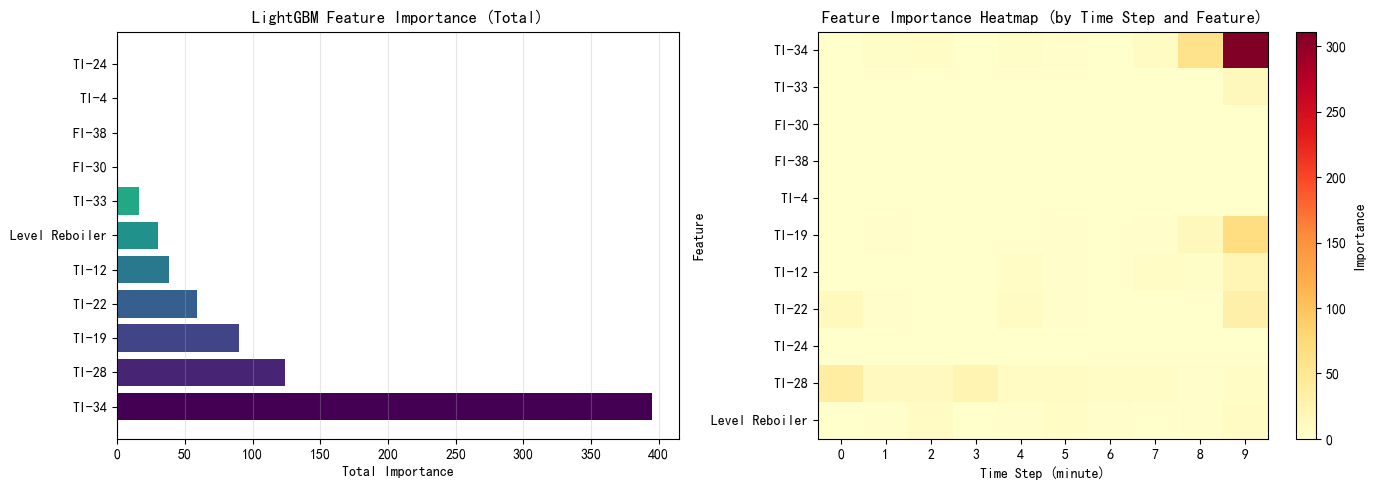


✓ Feature-importance plots saved as 'feature_importance_analysis.png'


In [10]:
# Get LightGBM feature importances
feature_importance = final_model.feature_importances_

# Input is flattened sliding windows, so reshape it
# Shape: (10 minutes × 11 features) = 110 dimensions
n_features_per_window = len(selected_features)
window_size = 10

# Group importance by time step and feature
importance_matrix = feature_importance.reshape(window_size, n_features_per_window)

# Total importance of each feature across all time steps
feature_total_importance = importance_matrix.sum(axis=0)
feature_importance_df = pd.DataFrame({
    'Feature': selected_features,
    'Total Importance': feature_total_importance,
    'Mean Importance': feature_total_importance / window_size
}).sort_values('Total Importance', ascending=False)

print("\n[Feature Importance Analysis (LightGBM)]")
print(feature_importance_df.to_string(index=False))

# Visualize feature importance
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: bar chart of total feature importance
ax1 = axes[0]
colors = plt.cm.viridis(np.linspace(0, 1, len(feature_importance_df)))
bars = ax1.barh(range(len(feature_importance_df)), feature_importance_df['Total Importance'], color=colors)
ax1.set_yticks(range(len(feature_importance_df)))
ax1.set_yticklabels(feature_importance_df['Feature'])
ax1.set_xlabel('Total Importance', fontweight='bold')
ax1.set_title('LightGBM Feature Importance (Total)', fontweight='bold')
ax1.grid(True, alpha=0.3, axis='x')

# Plot 2: heatmap of feature importance across time steps
ax2 = axes[1]
im = ax2.imshow(importance_matrix.T, aspect='auto', cmap='YlOrRd')
ax2.set_xlabel('Time Step (minute)', fontweight='bold')
ax2.set_ylabel('Feature', fontweight='bold')
ax2.set_xticks(range(window_size))
ax2.set_yticks(range(len(selected_features)))
ax2.set_yticklabels(selected_features)
ax2.set_title('Feature Importance Heatmap (by Time Step and Feature)', fontweight='bold')
cbar = plt.colorbar(im, ax=ax2)
cbar.set_label('Importance', fontweight='bold')

plt.tight_layout()
plt.savefig('feature_importance_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n✓ Feature-importance plots saved as 'feature_importance_analysis.png'")

## Step 9: Summary and File Export

In [11]:
# Create summary report
summary_report = f"""
{'='*80}
LightGBM Time Series Prediction Performance Summary
{'='*80}

[Data Configuration]
  • Number of original data points: {len(df)}
  • Sampling frequency: 1 minute per record
  • Time span: approximately {len(df)} minutes
  • Number of selected features: {len(selected_features)}

[Data Split]
  • Raw training set: {len(X_train_raw)} rows (first 80%)
  • Raw test set: {len(X_test_raw)} rows (last 20%)
  • Training windows: {len(X_train_windows)}
  • Test windows: {len(X_test_windows)}

[Model Configuration]
  • Model type: LightGBM Regressor
  • Algorithm: Light Gradient Boosting Machine
  • Optimization method: RandomizedSearchCV (3-fold cross-validation)
  • Input feature dimension: {X_train_windows.shape[1]} (10 minutes × {len(selected_features)} features)

[Best Hyperparameters]
  • n_estimators: {best_params['n_estimators']}
  • max_depth: {best_params['max_depth']}
  • num_leaves: {best_params['num_leaves']}
  • learning_rate: {best_params['learning_rate']:.6f}
  • min_child_samples: {best_params['min_child_samples']}
  • subsample: {best_params['subsample']:.4f}
  • colsample_bytree: {best_params['colsample_bytree']:.4f}
  • min_child_weight: {best_params['min_child_weight']:.6f}
  • reg_lambda (L2 regularization): 2.0
  • reg_alpha (L1 regularization): 0.5

[RandomizedSearchCV Results]
  • Cross-validation CV R²: {random_search.best_score_:.4f}
  • Search iterations: 30
  • Number of CV folds: 3

[Performance Metrics]
  Training set:
    • R²: {train_r2:.4f}
    • RMSE: {train_rmse:.6f}
    • MAE: {train_mae:.6f}
    • WQL: {train_wql:.6f}

  Test set:
    • R²: {test_r2:.4f}
    • RMSE: {test_rmse:.6f}
    • MAE: {test_mae:.6f}
    • WQL: {test_wql:.6f}

[Metric Interpretation]
  • R² (coefficient of determination): explained variance ratio, range [0, 1], higher is better
  • RMSE (root mean squared error): square-root of mean squared error, more sensitive to large deviations
  • MAE (mean absolute error): average absolute deviation, generally more robust
  • WQL (weighted quantile loss): measures symmetry and balance of prediction errors
    └─ When prediction < actual (underestimation), loss weight is 0.5
    └─ When prediction > actual (overestimation), loss weight is 0.5
    └─ Smaller WQL indicates more balanced predictions with less systematic bias

[Prediction Accuracy Interpretation]
  • R² = {test_r2:.4f}: the model explains {test_r2*100:.2f}% of target variance on the test set
  • RMSE = {test_rmse:.6f}: average prediction error (on original data scale)
  • MAE = {test_mae:.6f}: average absolute deviation
  • WQL = {test_wql:.6f}: prediction balance indicator (closer to 0 is better)

[Residual Analysis]
  • Residual mean: {residuals_mean:.6f} (close to 0 indicates unbiased prediction)
  • Residual standard deviation: {residuals_std:.6f}
  • Residual range: [{residuals.min():.6f}, {residuals.max():.6f}]

[Top 5 Important Features]
  • {feature_importance_df.iloc[0]['Feature']}: {feature_importance_df.iloc[0]['Total Importance']:.4f}
  • {feature_importance_df.iloc[1]['Feature']}: {feature_importance_df.iloc[1]['Total Importance']:.4f}
  • {feature_importance_df.iloc[2]['Feature']}: {feature_importance_df.iloc[2]['Total Importance']:.4f}
  • {feature_importance_df.iloc[3]['Feature']}: {feature_importance_df.iloc[3]['Total Importance']:.4f}
  • {feature_importance_df.iloc[4]['Feature']}: {feature_importance_df.iloc[4]['Total Importance']:.4f}

[Key Improvements]
  1. RandomizedSearchCV: randomly explores hyperparameter combinations and selects the best via 3-fold CV
  2. LightGBM: compared with random forest, gradient boosting usually provides stronger learning capacity for time-series prediction
  3. Chronological split: training and test sets are strictly split by time order to avoid data leakage
  4. Enhanced regularization: both L1 and L2 regularization are used to reduce overfitting

{'='*80}
"""

print(summary_report)

# Save report to file
with open('time_series_prediction_report.txt', 'w', encoding='utf-8') as f:
    f.write(summary_report)

print("\n✓ Report saved as 'time_series_prediction_report.txt'")


LightGBM Time Series Prediction Performance Summary

[Data Configuration]
  • Number of original data points: 7200
  • Sampling frequency: 1 minute per record
  • Time span: approximately 7200 minutes
  • Number of selected features: 11

[Data Split]
  • Raw training set: 5760 rows (first 80%)
  • Raw test set: 1440 rows (last 20%)
  • Training windows: 5750
  • Test windows: 1430

[Model Configuration]
  • Model type: LightGBM Regressor
  • Algorithm: Light Gradient Boosting Machine
  • Optimization method: RandomizedSearchCV (3-fold cross-validation)
  • Input feature dimension: 110 (10 minutes × 11 features)

[Best Hyperparameters]
  • n_estimators: 149
  • max_depth: 3
  • num_leaves: 22
  • learning_rate: 0.010016
  • min_child_samples: 28
  • subsample: 0.7335
  • colsample_bytree: 0.7619
  • min_child_weight: 0.004048
  • reg_lambda (L2 regularization): 2.0
  • reg_alpha (L1 regularization): 0.5

[RandomizedSearchCV Results]
  • Cross-validation CV R²: 0.2024
  • Search iterati

In [12]:
# Save predictions to CSV
results_df = pd.DataFrame({
    'Time Step': np.arange(len(y_test_windows)),
    'Actual Value': y_test_windows,
    'Predicted Value': y_test_pred,
    'Residual': residuals,
    'Absolute Error': np.abs(residuals),
    'Relative Error (%)': np.abs(residuals) / np.abs(y_test_windows) * 100
})

results_df.to_csv('time_series_predictions.csv', index=False, encoding='utf-8-sig')
print("✓ Prediction results saved as 'time_series_predictions.csv'")

# Save performance metrics summary
metrics_summary = pd.DataFrame({
    'Metric': ['R²', 'RMSE', 'MAE', 'Residual Mean', 'Residual Std'],
    'Training Set': [train_r2, train_rmse, train_mae, np.nan, np.nan],
    'Test Set': [test_r2, test_rmse, test_mae, residuals_mean, residuals_std]
})

metrics_summary.to_csv('performance_metrics.csv', index=False, encoding='utf-8-sig')
print("✓ Performance metrics saved as 'performance_metrics.csv'")

print("\n" + "="*80)
print("✅ All files have been generated successfully!")
print("="*80)
print("\nGenerated files:")
print("  1. time_series_prediction_results.png - Prediction visualization")
print("  2. feature_importance_analysis.png - Feature importance analysis")
print("  3. time_series_prediction_report.txt - Performance summary report")
print("  4. time_series_predictions.csv - Detailed prediction results")
print("  5. performance_metrics.csv - Performance metrics summary")

✓ Prediction results saved as 'time_series_predictions.csv'
✓ Performance metrics saved as 'performance_metrics.csv'

✅ All files have been generated successfully!

Generated files:
  1. time_series_prediction_results.png - Prediction visualization
  2. feature_importance_analysis.png - Feature importance analysis
  3. time_series_prediction_report.txt - Performance summary report
  4. time_series_predictions.csv - Detailed prediction results
  5. performance_metrics.csv - Performance metrics summary
